To run this, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance!
<div class="align-center">
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://docs.unsloth.ai/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a></a> Join Discord if you need help + ⭐ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐
</div>

To install Unsloth on your own computer, follow the installation instructions on our Github page [here](https://docs.unsloth.ai/get-started/installing-+-updating).

You will learn how to do [data prep](#Data), how to [train](#Train), how to [run the model](#Inference), & [how to save it](#Save)


### News

**NEW** Unsloth now supports training the new **gpt-oss** model from OpenAI! You can start finetune gpt-oss for free with our **[Colab notebook](https://x.com/UnslothAI/status/1953896997867729075)**!

Unsloth now supports Text-to-Speech (TTS) models. Read our [guide here](https://docs.unsloth.ai/basics/text-to-speech-tts-fine-tuning).

Read our **[Gemma 3N Guide](https://docs.unsloth.ai/basics/gemma-3n-how-to-run-and-fine-tune)** and check out our new **[Dynamic 2.0](https://docs.unsloth.ai/basics/unsloth-dynamic-2.0-ggufs)** quants which outperforms other quantization methods!

Visit our docs for all our [model uploads](https://docs.unsloth.ai/get-started/all-our-models) and [notebooks](https://docs.unsloth.ai/get-started/unsloth-notebooks).


### Installation

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9\.]{3,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + "0.0.32.post2" if v == "2.8.0" else "0.0.29.post3"
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1,<4.0.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth

### Unsloth

In [ ]:
from unsloth import FastLanguageModel
import torch
max_seq_length = 2048 # Choose any! We auto support RoPE Scaling internally!
dtype = None # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
load_in_4bit = False # Use 4bit quantization to reduce memory usage. Can be False.
load_in_8bit = True

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Meta-Llama-3.1-8B-bnb-4bit",      # Llama-3.1 2x faster
    "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    "unsloth/Meta-Llama-3.1-70B-bnb-4bit",
    "unsloth/Meta-Llama-3.1-405B-bnb-4bit",    # 4bit for 405b!
    "unsloth/Mistral-Small-Instruct-2409",     # Mistral 22b 2x faster!
    "unsloth/mistral-7b-instruct-v0.3-bnb-4bit",
    "unsloth/Phi-3.5-mini-instruct",           # Phi-3.5 2x faster!
    "unsloth/Phi-3-medium-4k-instruct",
    "unsloth/gemma-2-9b-bnb-4bit",
    "unsloth/gemma-2-27b-bnb-4bit",            # Gemma 2x faster!

    "unsloth/Llama-3.2-1B-bnb-4bit",           # NEW! Llama 3.2 models
    "unsloth/Llama-3.2-1B-Instruct-bnb-4bit",
    "unsloth/Llama-3.2-3B-bnb-4bit",
    "unsloth/Llama-3.2-3B-Instruct-bnb-4bit",

    "unsloth/Llama-3.3-70B-Instruct-bnb-4bit" # NEW! Llama 3.3 70B!
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "meta-llama/Llama-3.2-3B", # or choose "unsloth/Llama-3.2-1B-Instruct"
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit=load_in_4bit,
    load_in_8bit = load_in_8bit,
    token = "hf...", # use one if using gated models like meta-llama/Llama-2-7b-hf
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.8.9: Fast Llama patching. Transformers: 4.55.4.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/230 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

We now add LoRA adapters so we only need to update 1 to 10% of all parameters!

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    # [NEW] "unsloth" uses 30% less VRAM, fits 2x larger batch sizes!
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
)

Unsloth: Making `model.base_model.model.model` require gradients


<a name="Data"></a>
### Data Prep
We now use the `Llama-3.1` format for conversation style finetunes. We use [Maxime Labonne's FineTome-100k](https://huggingface.co/datasets/mlabonne/FineTome-100k) dataset in ShareGPT style. But we convert it to HuggingFace's normal multiturn format `("role", "content")` instead of `("from", "value")`/ Llama-3 renders multi turn conversations like below:

```
<|begin_of_text|><|start_header_id|>user<|end_header_id|>

Hello!<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Hey there! How are you?<|eot_id|><|start_header_id|>user<|end_header_id|>

I'm great thanks!<|eot_id|>
```

We use our `get_chat_template` function to get the correct chat template. We support `zephyr, chatml, mistral, llama, alpaca, vicuna, vicuna_old, phi3, llama3` and more.

In [ ]:
from unsloth.chat_templates import get_chat_template
from datasets import load_dataset
import json

tokenizer = get_chat_template(
    tokenizer,
    chat_template = "llama-3.1",
)

# Load your dataset
dataset = load_dataset("parquet", data_files="datasetV1_train.parquet", split="train")

# First, let's debug what your data actually looks like
print("Dataset columns:", dataset.column_names)
print("First example:", dataset[0])
print("Type of conversation:", type(dataset[0]["conversation"]))
print("First conversation:", dataset[0]["conversation"])

def convert_to_standard_format(examples):
    """Convert your format to the standard chat format expected by the tokenizer"""
    conversations = []

    for convo in examples["conversation"]:
        # Check if conversation is a string that needs parsing
        if isinstance(convo, str):
            try:
                convo = json.loads(convo)
            except json.JSONDecodeError:
                print(f"Failed to parse conversation: {convo}")
                continue

        # Convert each conversation from your format to standard format
        converted_convo = []
        for message in convo:
            # Handle case where message might be a string
            if isinstance(message, str):
                try:
                    message = json.loads(message)
                except json.JSONDecodeError:
                    print(f"Failed to parse message: {message}")
                    continue

            # Map "from" to "role" and "value" to "content"
            role = message.get("from", message.get("role", ""))
            content = message.get("value", message.get("content", ""))

            # Convert "human" to "user" and "gpt" to "assistant"
            if role == "human":
                role = "user"
            elif role == "gpt":
                role = "assistant"

            converted_message = {
                "role": role,
                "content": content
            }
            converted_convo.append(converted_message)
        conversations.append(converted_convo)

    return {"conversation": conversations}

def formatting_prompts_func(examples):
    convos = examples["conversation"]
    texts = []
    for convo in convos:
        try:
            text = tokenizer.apply_chat_template(convo, tokenize=False, add_generation_prompt=False)
            texts.append(text)
        except Exception as e:
            print(f"Error formatting conversation: {e}")
            print(f"Conversation: {convo}")
            texts.append("")  # Add empty string as fallback
    return {"text": texts}

# Alternative: If you want to handle the conversion manually without using the map function first
def debug_single_example():
    """Debug a single example to understand the data structure"""
    example = dataset[0]["conversation"]
    print(f"Raw conversation: {example}")
    print(f"Type: {type(example)}")

    if isinstance(example, str):
        try:
            parsed = json.loads(example)
            print(f"Parsed conversation: {parsed}")
        except json.JSONDecodeError as e:
            print(f"JSON parse error: {e}")

# Run debug function first
debug_single_example()

# Then try the conversion
print("\nTrying conversion...")
try:
    dataset = dataset.map(convert_to_standard_format, batched=True)
    dataset = dataset.map(formatting_prompts_func, batched=True)

    print("Conversion successful!")
    print("Sample formatted text:")
    print(dataset[0]["text"][:500] + "...")
except Exception as e:
    print(f"Conversion failed: {e}")
    print("Please share the debug output above for further help.")

Generating train split: 0 examples [00:00, ? examples/s]

Dataset columns: ['conversation', 'source', 'score']
First example: {'conversation': '[{"from": "human", "value": "Bagaimana status akhir dari barang bukti berupa telepon genggam dan sejumlah uang tunai yang disita dalam perkara ini berdasarkan amar putusan hakim?"}, {"from": "gpt", "value": "Dalam amar putusannya, Majelis Hakim menetapkan bahwa barang bukti yang menjadi alat dan hasil kejahatan harus disita dari Terdakwa. Untuk barang bukti berupa 1 unit telepon genggam merk VIVO Y01, yang merupakan alat utama yang digunakan untuk melakukan kejahatan (mengoperasikan MiChat), serta uang tunai sejumlah total Rp 1.017.000,- yang merupakan hasil dari tindak pidana, semuanya ditetapkan untuk dirampas untuk negara. Sementara itu, barang bukti berupa satu buah kondom bekas pakai dirampas untuk dimusnahkan."}]', 'source': 'Gemini 2.5 pro', 'score': None}
Type of conversation: <class 'str'>
First conversation: [{"from": "human", "value": "Bagaimana status akhir dari barang bukti berupa telepon

Map:   0%|          | 0/822 [00:00<?, ? examples/s]

Map:   0%|          | 0/822 [00:00<?, ? examples/s]

Conversion successful!
Sample formatted text:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 July 2024

<|eot_id|><|start_header_id|>user<|end_header_id|>

Bagaimana status akhir dari barang bukti berupa telepon genggam dan sejumlah uang tunai yang disita dalam perkara ini berdasarkan amar putusan hakim?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Dalam amar putusannya, Majelis Hakim menetapkan bahwa barang bukti yang menjadi alat dan hasil kejahatan harus disita...


In [ ]:
# from unsloth.chat_templates import get_chat_template

# tokenizer = get_chat_template(
#     tokenizer,
#     chat_template = "llama-3.1",
# )

# def formatting_prompts_func(examples):
#     convos = examples["conversation"]
#     texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False) for convo in convos]
#     return { "text" : texts, }
# pass

# from datasets import load_dataset
# dataset = load_dataset("parquet", data_files="test_data.parquet", split="train")

We now use `standardize_sharegpt` to convert ShareGPT style datasets into HuggingFace's generic format. This changes the dataset from looking like:
```
{"from": "system", "value": "You are an assistant"}
{"from": "human", "value": "What is 2+2?"}
{"from": "gpt", "value": "It's 4."}
```
to
```
{"role": "system", "content": "You are an assistant"}
{"role": "user", "content": "What is 2+2?"}
{"role": "assistant", "content": "It's 4."}
```

In [ ]:
from unsloth.chat_templates import standardize_sharegpt
dataset = standardize_sharegpt(dataset)
dataset = dataset.map(formatting_prompts_func, batched = True,)

Map:   0%|          | 0/822 [00:00<?, ? examples/s]

We look at how the conversations are structured for item 5:

In [ ]:
dataset[5]["conversation"]

[{'content': 'Apa saja barang bukti yang dihadirkan di persidangan yang menunjukkan Terdakwa menerima keuntungan finansial dari perbuatannya?',
  'role': 'user'},
 {'content': 'Bukti kunci yang menunjukkan Terdakwa memperoleh keuntungan finansial adalah uang tunai sebesar Rp4.000.000,00 yang disita darinya. Dalam persidangan, Terdakwa mengakui bahwa uang tersebut ia terima dari dua orang calon pekerja migran sebagai biaya pengurusan keberangkatan mereka ke Malaysia. Pengakuan ini, ditambah dengan barang bukti fisik berupa uang tunai dan sebuah telepon genggam yang digunakan untuk berkomunikasi, menjadi dasar kuat bagi hakim untuk menyatakan bahwa Terdakwa melakukan perbuatan tersebut dengan motif ekonomi. Pengadilan akhirnya memutuskan agar uang dan telepon genggam tersebut dirampas untuk negara.',
  'role': 'assistant'}]

And we see how the chat template transformed these conversations.

**[Notice]** Llama 3.1 Instruct's default chat template default adds `"Cutting Knowledge Date: December 2023\nToday Date: 26 July 2024"`, so do not be alarmed!

In [ ]:
dataset[5]["text"]

'<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 July 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nApa saja barang bukti yang dihadirkan di persidangan yang menunjukkan Terdakwa menerima keuntungan finansial dari perbuatannya?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nBukti kunci yang menunjukkan Terdakwa memperoleh keuntungan finansial adalah uang tunai sebesar Rp4.000.000,00 yang disita darinya. Dalam persidangan, Terdakwa mengakui bahwa uang tersebut ia terima dari dua orang calon pekerja migran sebagai biaya pengurusan keberangkatan mereka ke Malaysia. Pengakuan ini, ditambah dengan barang bukti fisik berupa uang tunai dan sebuah telepon genggam yang digunakan untuk berkomunikasi, menjadi dasar kuat bagi hakim untuk menyatakan bahwa Terdakwa melakukan perbuatan tersebut dengan motif ekonomi. Pengadilan akhirnya memutuskan agar uang dan telepon genggam tersebut dirampas untuk negara

<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`. We also support TRL's `DPOTrainer`!

In [ ]:
from trl import SFTConfig, SFTTrainer
from transformers import DataCollatorForSeq2Seq
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    data_collator = DataCollatorForSeq2Seq(tokenizer = tokenizer),
    packing = False, # Can make training 5x faster for short sequences.
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        num_train_epochs = 5, # Set this for 1 full training run.
        max_steps = 100,
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none", # Use this for WandB etc
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/822 [00:00<?, ? examples/s]

We also use Unsloth's `train_on_completions` method to only train on the assistant outputs and ignore the loss on the user's inputs.

In [ ]:
from unsloth.chat_templates import train_on_responses_only
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|start_header_id|>user<|end_header_id|>\n\n",
    response_part = "<|start_header_id|>assistant<|end_header_id|>\n\n",
)

Map (num_proc=2):   0%|          | 0/822 [00:00<?, ? examples/s]

We verify masking is actually done:

In [ ]:
tokenizer.decode(trainer.train_dataset[5]["input_ids"])

'<|begin_of_text|><|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 July 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nApa saja barang bukti yang dihadirkan di persidangan yang menunjukkan Terdakwa menerima keuntungan finansial dari perbuatannya?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nBukti kunci yang menunjukkan Terdakwa memperoleh keuntungan finansial adalah uang tunai sebesar Rp4.000.000,00 yang disita darinya. Dalam persidangan, Terdakwa mengakui bahwa uang tersebut ia terima dari dua orang calon pekerja migran sebagai biaya pengurusan keberangkatan mereka ke Malaysia. Pengakuan ini, ditambah dengan barang bukti fisik berupa uang tunai dan sebuah telepon genggam yang digunakan untuk berkomunikasi, menjadi dasar kuat bagi hakim untuk menyatakan bahwa Terdakwa melakukan perbuatan tersebut dengan motif ekonomi. Pengadilan akhirnya memutuskan agar uang dan telepon genggam tersebut dira

In [ ]:
space = tokenizer(" ", add_special_tokens = False).input_ids[0]
tokenizer.decode([space if x == -100 else x for x in trainer.train_dataset[5]["labels"]])

'                                                                        Bukti kunci yang menunjukkan Terdakwa memperoleh keuntungan finansial adalah uang tunai sebesar Rp4.000.000,00 yang disita darinya. Dalam persidangan, Terdakwa mengakui bahwa uang tersebut ia terima dari dua orang calon pekerja migran sebagai biaya pengurusan keberangkatan mereka ke Malaysia. Pengakuan ini, ditambah dengan barang bukti fisik berupa uang tunai dan sebuah telepon genggam yang digunakan untuk berkomunikasi, menjadi dasar kuat bagi hakim untuk menyatakan bahwa Terdakwa melakukan perbuatan tersebut dengan motif ekonomi. Pengadilan akhirnya memutuskan agar uang dan telepon genggam tersebut dirampas untuk negara.<|eot_id|>'

We can see the System and Instruction prompts are successfully masked!

In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.741 GB.
6.127 GB of memory reserved.


In [ ]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 822 | Num Epochs = 1 | Total steps = 100
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,1.895300
2,1.948200
3,1.764000
4,1.933300
5,1.750300
6,1.784400
7,1.733700
8,1.636400
9,1.740900
10,1.701500


In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

332.8742 seconds used for training.
5.55 minutes used for training.
Peak reserved memory = 6.695 GB.
Peak reserved memory for training = 0.568 GB.
Peak reserved memory % of max memory = 45.418 %.
Peak reserved memory for training % of max memory = 3.853 %.


<a name="Inference"></a>
### Inference
Let's run the model! You can change the instruction and input - leave the output blank!



We use `min_p = 0.1` and `temperature = 1.5`. Read this [Tweet](https://x.com/menhguin/status/1826132708508213629) for more information on why.

In [ ]:
from unsloth.chat_templates import get_chat_template

tokenizer = get_chat_template(
    tokenizer,
    chat_template = "llama-3.1",
)
FastLanguageModel.for_inference(model) # Enable native 2x faster inference

messages = [
    {"role": "user", "content": "Continue the fibonnaci sequence: 1, 1, 2, 3, 5, 8,"},
]
inputs = tokenizer.apply_chat_template(
    messages,
    tokenize = True,
    add_generation_prompt = True, # Must add for generation
    return_tensors = "pt",
).to("cuda")

outputs = model.generate(input_ids = inputs, max_new_tokens = 64, use_cache = True,
                         temperature = 1.5, min_p = 0.1)
tokenizer.batch_decode(outputs)

['<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 July 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nContinue the fibonnaci sequence: 1, 1, 2, 3, 5, 8,<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nThe fibonnaci sequence: 1, 1, 2, 3, 5, 8, 13, 21,... is an infinite series of numbers where each number is the sum of the two previous numbers. To continue the sequence, you need to take the two previous terms in the']

 You can also use a `TextStreamer` for continuous inference - so you can see the generation token by token, instead of waiting the whole time!

In [ ]:
FastLanguageModel.for_inference(model) # Enable native 2x faster inference

messages = [
    {"role": "user", "content": "Ringkasan Kasus: Putusan No. 178/Pid.Sus/2023/PN.Btm Terdakwa: AS (Laki-laki, 35 tahun) Korban: IK (Perempuan, 19 tahun) Ringkasan: Terdakwa, AS, didakwa telah merekrut korban, IK, dari desanya di Jawa Barat dengan janji palsu pekerjaan bergaji tinggi sebagai pramuria restoran di Singapura. Terdakwa mengurus paspor dan perjalanan IK ke Batam. Di Batam, IK disekap di sebuah penampungan sementara dan dokumennya disita. AS kemudian berupaya menyelundupkannya ke Malaysia untuk dipekerjakan dalam prostitusi paksa. Rencana tersebut digagalkan ketika pihak berwenang menggerebek tempat penampungan tersebut sebelum korban sempat diberangkatkan ke luar negeri. Tuntutan Jaksa: Jaksa Penuntut Umum (JPU) menuntut AS dengan dakwaan melanggar Pasal 2 Ayat 1 Undang-Undang No. 21 Tahun 2007 tentang Pemberantasan Tindak Pidana Perdagangan Orang (UU PTPPO), dengan tuntutan pidana penjara selama 7 tahun. Pertimbangan Hukum Hakim: Majelis Hakim menemukan bahwa tindakan terdakwa telah memenuhi unsur-unsur perekrutan dan penipuan sebagaimana diatur dalam UU PTPPO. Namun, hakim mencatat adanya faktor yang meringankan: terdakwa baru pertama kali melakukan tindak pidana dan menunjukkan penyesalan selama persidangan. Hakim juga mempertimbangkan fakta bahwa tindak pidana perdagangan orang belum selesai sepenuhnya, karena korban berhasil diselamatkan sebelum dikirim ke luar negeri. Hal ini dipertimbangkan dengan faktor yang memberatkan, yaitu adanya perencanaan yang jelas (niat jahat). Amar Putusan: Majelis Hakim menyatakan AS terbukti bersalah melakukan *percobaan* tindak pidana perdagangan orang. Terdakwa dijatuhi hukuman 4 tahun penjara dan denda, berdasarkan penerapan primer Pasal 2 Ayat 1 UU PTPPO juncto Pasal 53 Kitab Undang-Undang Hukum Pidana (KUHP) tentang percobaan melakukan kejahatan. Jawablah pertanyaan ini berdasarkan ringkasan kasus tersebut Berdasarkan ringkasan kasus yang diberikan, analisis diskrepansi antara tuntutan jaksa yaitu 7 tahun penjara dengan vonis akhir hakim yaitu 4 tahun penjara. Jelaskan bagaimana hakim menyeimbangkan faktor yang meringankan (pelaku baru pertama kali, adanya penyesalan) dengan faktor yang memberatkan (adanya perencanaan), dan rincikan dasar pertimbangan hukum hakim dalam menerapkan Pasal 53 KUHP (tentang percobaan tindak pidana) juncto UU PTPPO untuk memberikan putusan yang lebih ringan tersebut. DALAM BENTUK PARAGRAF TIDAK ADA BULLET POINT ATAU APAPUN "},
]
inputs = tokenizer.apply_chat_template(
    messages,
    tokenize = True,
    add_generation_prompt = True, # Must add for generation
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(input_ids = inputs, streamer = text_streamer, max_new_tokens = 2048,
                   use_cache = True, temperature = 1.0, min_p = 0.1)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 July 2024

<|eot_id|><|start_header_id|>user<|end_header_id|>

Ringkasan Kasus: Putusan No. 178/Pid.Sus/2023/PN.Btm Terdakwa: AS (Laki-laki, 35 tahun) Korban: IK (Perempuan, 19 tahun) Ringkasan: Terdakwa, AS, didakwa telah merekrut korban, IK, dari desanya di Jawa Barat dengan janji palsu pekerjaan bergaji tinggi sebagai pramuria restoran di Singapura. Terdakwa mengurus paspor dan perjalanan IK ke Batam. Di Batam, IK disekap di sebuah penampungan sementara dan dokumennya disita. AS kemudian berupaya menyelundupkannya ke Malaysia untuk dipekerjakan dalam prostitusi paksa. Rencana tersebut digagalkan ketika pihak berwenang menggerebek tempat penampungan tersebut sebelum korban sempat diberangkatkan ke luar negeri. Tuntutan Jaksa: Jaksa Penuntut Umum (JPU) menuntut AS dengan dakwaan melanggar Pasal 2 Ayat 1 Undang-Undang No. 21 Tahun 2007 tentang Pemberantasan Tindak Pidana Pe

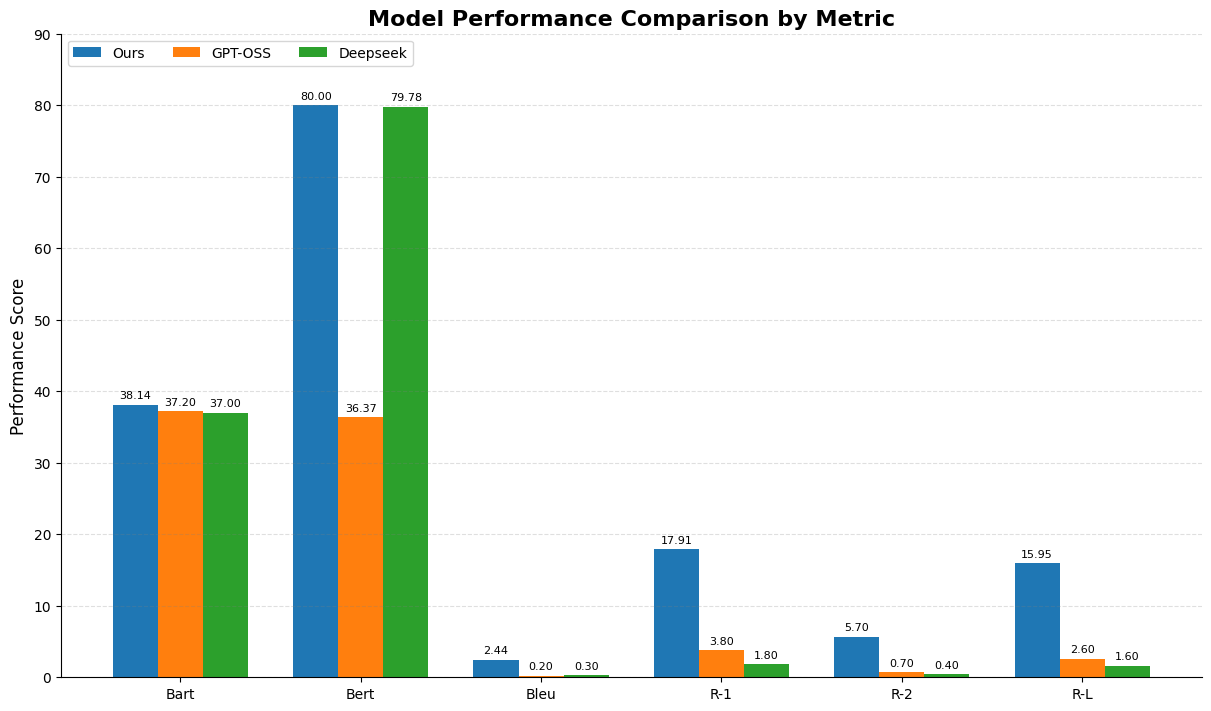

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your table
models = ['Ours', 'GPT-OSS', 'Deepseek']
metrics = ['Bart', 'Bert', 'Bleu', 'R-1', 'R-2', 'R-L']
data = {
    'Ours': [38.14, 80, 2.44, 17.91, 5.7, 15.95],
    'GPT-OSS': [37.2, 36.37, 0.2, 3.8, 0.7, 2.6],
    'Deepseek': [37, 79.78, 0.3, 1.8, 0.4, 1.6]
}

# --- Plotting ---
x = np.arange(len(metrics))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

# Set up the plot and figure size
fig, ax = plt.subplots(figsize=(12, 7), layout='constrained')

# Iterate through each model to plot its bars
for model_name, model_data in data.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, model_data, width, label=model_name)
    ax.bar_label(rects, padding=3, fmt='%.2f', fontsize=8)
    multiplier += 1

# --- Aesthetics and Labels ---
ax.set_ylabel('Performance Score', fontsize=12)
ax.set_title('Model Performance Comparison by Metric', fontsize=16, fontweight='bold')
ax.set_xticks(x + width, metrics, fontsize=10)
ax.legend(loc='upper left', ncols=3, fontsize=10)
ax.set_ylim(0, 90) # Adjust y-axis limit to give space for labels

# Add a grid for better readability
ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=.25)

# Remove top and right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Display the plot
plt.show()

<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Huggingface's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [ ]:
model.save_pretrained("lora_model")  # Local saving
tokenizer.save_pretrained("lora_model")
# model.push_to_hub("your_name/lora_model", token = "...") # Online saving
# tokenizer.push_to_hub("your_name/lora_model", token = "...") # Online saving

('lora_model/tokenizer_config.json',
 'lora_model/special_tokens_map.json',
 'lora_model/chat_template.jinja',
 'lora_model/tokenizer.json')

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [ ]:
from unsloth import FastLanguageModel
import torch
max_seq_length = 2048 # Choose any! We auto support RoPE Scaling internally!
dtype = None # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
load_in_4bit = False # Use 4bit quantization to reduce memory usage. Can be False.
load_in_8bit = True

if True:
    from unsloth import FastLanguageModel
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = "lora_model", # YOUR MODEL YOU USED FOR TRAINING
        max_seq_length = max_seq_length,
        dtype = dtype,
        load_in_4bit = load_in_4bit,
        load_in_8bit = load_in_8bit,
    )
    FastLanguageModel.for_inference(model) # Enable native 2x faster inference

messages = [
    {"role": "user", "content": "Describe a tall tower in the capital of France."},
]
inputs = tokenizer.apply_chat_template(
    messages,
    tokenize = True,
    add_generation_prompt = True, # Must add for generation
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(input_ids = inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.8.9: Fast Llama patching. Transformers: 4.55.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 July 2024

<|eot_id|><|start_header_id|>user<|end_header_id|>

Describe a tall tower in the capital of France.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

A striking sight to behold is the Eiffel Tower in the heart of Paris. This famous structure stands tall at 324 meters, making it one of the highest structures in Europe. Completed in 1889 to commemorate the centennial celebration of the French Revolution, this tower was not designed to last, but rather to be an ephemeral architectural exhibit. Over time, the structure has endured, becoming an icon of French engineering and culture. From a distance, it is one of the most recognizable landmarks in the world. A visit to the observation deck provides stunning panoramic views of Paris and the surrounding area, allowing visitors to appreciate its grandeur


You can also use Hugging Face's `AutoModelForPeftCausalLM`. Only use this if you do not have `unsloth` installed. It can be hopelessly slow, since `4bit` model downloading is not supported, and Unsloth's **inference is 2x faster**.

In [ ]:
if False:
    # I highly do NOT suggest - use Unsloth if possible
    from peft import AutoPeftModelForCausalLM
    from transformers import AutoTokenizer
    model = AutoPeftModelForCausalLM.from_pretrained(
        "lora_model", # YOUR MODEL YOU USED FOR TRAINING
        load_in_4bit = load_in_4bit,
    )
    tokenizer = AutoTokenizer.from_pretrained("lora_model")

### Saving to float16 for VLLM

We also support saving to `float16` directly. Select `merged_16bit` for float16 or `merged_4bit` for int4. We also allow `lora` adapters as a fallback. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens.

In [ ]:
# Merge to 16bit
if True: model.save_pretrained_merged("model", tokenizer, save_method = "merged_16bit",)
if False: model.push_to_hub_merged("hf/model", tokenizer, save_method = "merged_16bit", token = "")

# Merge to 4bit
if False: model.save_pretrained_merged("model", tokenizer, save_method = "merged_4bit",)
if False: model.push_to_hub_merged("hf/model", tokenizer, save_method = "merged_4bit", token = "")

# Just LoRA adapters
if False:
    model.save_pretrained("model")
    tokenizer.save_pretrained("model")
if False:
    model.push_to_hub("hf/model", token = "")
    tokenizer.push_to_hub("hf/model", token = "")


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Successfully copied all 2 files from cache to model.


Unsloth: Merging weights into 16bit:   0%|          | 0/2 [00:00<?, ?it/s]

### GGUF / llama.cpp Conversion
To save to `GGUF` / `llama.cpp`, we support it natively now! We clone `llama.cpp` and we default save it to `q8_0`. We allow all methods like `q4_k_m`. Use `save_pretrained_gguf` for local saving and `push_to_hub_gguf` for uploading to HF.

Some supported quant methods (full list on our [Wiki page](https://github.com/unslothai/unsloth/wiki#gguf-quantization-options)):
* `q8_0` - Fast conversion. High resource use, but generally acceptable.
* `q4_k_m` - Recommended. Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q4_K.
* `q5_k_m` - Recommended. Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q5_K.

[**NEW**] To finetune and auto export to Ollama, try our [Ollama notebook](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3_(8B)-Ollama.ipynb)

In [ ]:
# Save to 8bit Q8_0
if True: model.save_pretrained_gguf("model", tokenizer,)
# Remember to go to https://huggingface.co/settings/tokens for a token!
# And change hf to your username!
if False: model.push_to_hub_gguf("hf/model", tokenizer, token = "")

# Save to 16bit GGUF
if False: model.save_pretrained_gguf("model", tokenizer, quantization_method = "f16")
if False: model.push_to_hub_gguf("hf/model", tokenizer, quantization_method = "f16", token = "")

# Save to q4_k_m GGUF
if False: model.save_pretrained_gguf("model", tokenizer, quantization_method = "q4_k_m")
if False: model.push_to_hub_gguf("hf/model", tokenizer, quantization_method = "q4_k_m", token = "")

# Save to multiple GGUF options - much faster if you want multiple!
if False:
    model.push_to_hub_gguf(
        "hf/model", # Change hf to your username!
        tokenizer,
        quantization_method = ["q4_k_m", "q8_0", "q5_k_m",],
        token = "", # Get a token at https://huggingface.co/settings/tokens
    )

Unsloth: Updating system package directories
Unsloth: Install GGUF and other packages
Unsloth GGUF:hf-to-gguf:Loading model: model
Unsloth GGUF:hf-to-gguf:Model architecture: LlamaForCausalLM
Unsloth GGUF:gguf.gguf_writer:gguf: This GGUF file is for Little Endian only
Unsloth GGUF:hf-to-gguf:Exporting model...
Unsloth GGUF:hf-to-gguf:rope_freqs.weight,           torch.float32 --> F32, shape = {64}
Unsloth GGUF:hf-to-gguf:gguf: loading model weight map from 'model.safetensors.index.json'
Unsloth GGUF:hf-to-gguf:gguf: loading model part 'model-00001-of-00002.safetensors'
Unsloth GGUF:hf-to-gguf:token_embd.weight,           torch.bfloat16 --> Q8_0, shape = {3072, 128256}
Unsloth GGUF:hf-to-gguf:gguf: loading model part 'model-00002-of-00002.safetensors'
Unsloth GGUF:hf-to-gguf:output_norm.weight,          torch.bfloat16 --> F32, shape = {3072}
Unsloth GGUF:hf-to-gguf:Set meta model
Unsloth GGUF:hf-to-gguf:Set model parameters
Unsloth GGUF:hf-to-gguf:gguf: context length = 131072
Unsloth G

Unsloth: GGUF conversion:   0%|          | 0/100 [00:00<?, ?it/s]

Unsloth GGUF:hf-to-gguf:Model successfully exported to ./
Unsloth: Converted to model.Q8_0.gguf with size = 3.4G
Unsloth: Successfully saved GGUF to:
model.Q8_0.gguf


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
from pathlib import Path

src = "modelV1.Q8_0.gguf"
dst = "/content/drive/MyDrive/legalLLM/models/modelV1.Q8_0.gguf"

# Create parent directory and copy in one go
Path(dst).parent.mkdir(parents=True, exist_ok=True)
shutil.copy(src, dst)
print("Saved to:", dst)

Saved to: /content/drive/MyDrive/legalLLM/models/modelV1.Q8_0.gguf


# Evaluation

In [ ]:
# Upgrade pip
!pip install -q --upgrade pip

# llama-cpp-python GPU wheel (CUDA 12.2) from the project's extra index — works on Colab T4
!pip install -q llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu122

# Metrics + tooling
!pip install -q datasets evaluate "bert-score" sacrebleu transformers sentencepiece tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
from pathlib import Path
from datasets import load_dataset
import json
from tqdm import tqdm

drive.mount('/content/drive')

MODEL_PATH = "/content/drive/MyDrive/legalLLM/models/modelV1.Q8_0.gguf"  # your GGUF
PARQUET_PATH = "datasetV1_test.parquet"     # your test set
OUTPUT_DIR = Path("/content/drive/MyDrive/legalLLM/eval_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load parquet exactly as requested
ds = load_dataset("parquet", data_files=PARQUET_PATH, split="train")
print("Rows:", len(ds), "Columns:", ds.column_names)
assert "conversation" in ds.column_names, "Expected 'conversation' column"


Mounted at /content/drive


Generating train split: 0 examples [00:00, ? examples/s]

Rows: 206 Columns: ['conversation', 'source', 'score']


In [ ]:
from typing import List, Tuple

def extract_pairs_from_conversation(conv_field) -> List[Tuple[str,str]]:
    """
    Extract (prompt, reference) where prompt is the human turn and reference is the *next* assistant/gpt turn.
    conv_field is a JSON string or a Python list like:
    [{"from":"human","value":"..."},{"from":"gpt","value":"..."}]
    """
    if isinstance(conv_field, str):
        conv = json.loads(conv_field)
    else:
        conv = conv_field
    pairs = []
    for i, entry in enumerate(conv):
        role = (entry.get("from","") or "").lower()
        val  = (entry.get("value","") or "").strip()
        if role == "human":
            nxt = conv[i+1] if i+1 < len(conv) else None
            if nxt:
                nrole = (nxt.get("from","") or "").lower()
                nval  = (nxt.get("value","") or "").strip()
                if nrole.startswith("gpt") or "assistant" in nrole or nrole.startswith("bot"):
                    pairs.append((val, nval))
                else:
                    pairs.append((val, ""))
            else:
                pairs.append((val, ""))
    return pairs

# quick peek
print(extract_pairs_from_conversation(ds[0]["conversation"])[:1])

[('Berdasarkan keterangan para saksi korban, bagaimana skema potong gaji yang diterapkan oleh Terdakwa dan mengapa skema tersebut dianggap sebagai bentuk eksploitasi?', 'Menurut keterangan para saksi korban seperti Silviana Anggit Anggrayni dan Suci Inayah, Terdakwa menerapkan skema potong gaji selama enam setengah bulan untuk menutupi biaya pemberangkatan ke Singapura. Akibat skema ini, para korban yang bekerja sebagai asisten rumah tangga tidak menerima sepeser pun gaji selama mereka bekerja. Sebagai contoh, saksi Silviana yang bekerja selama tiga bulan dan saksi Suci yang bekerja selama satu bulan, keduanya dipulangkan tanpa pernah menerima upah. Skema ini dianggap sebagai eksploitasi karena para pekerja telah memberikan tenaga dan waktu mereka, namun hak fundamental mereka atas upah dirampas sepenuhnya oleh Terdakwa demi keuntungan pribadi, menempatkan mereka dalam posisi yang rentan dan tereksploitasi secara ekonomi.')]


In [ ]:
from llama_cpp import Llama

llm = Llama(
    model_path=MODEL_PATH,
    n_ctx=2048,
    n_gpu_layers=100,   # offload as many layers as possible to T4 GPU
    n_batch=512,
    verbose=True
)

def generate_response(prompt: str, max_tokens: int = 256, temperature: float = 0.0):
    # Try chat-completion API first (works for most chat GGUFs)
    try:
        out = llm.create_chat_completion(
            messages=[{"role": "user", "content": prompt}],
            max_tokens=max_tokens,
            temperature=temperature,
        )
        return out["choices"][0]["message"]["content"].strip()
    except Exception:
        # Fallback to plain completion
        out = llm(prompt, max_tokens=max_tokens, temperature=temperature)
        return out["choices"][0]["text"].strip()


ggml_cuda_init: GGML_CUDA_FORCE_MMQ:    yes
ggml_cuda_init: GGML_CUDA_FORCE_CUBLAS: no
ggml_cuda_init: found 1 CUDA devices:
  Device 0: Tesla T4, compute capability 7.5, VMM: yes
llama_model_load_from_file_impl: using device CUDA0 (Tesla T4) - 14992 MiB free
llama_model_loader: loaded meta data with 32 key-value pairs and 255 tensors from /content/drive/MyDrive/legalLLM/models/modelV1.Q8_0.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Model
llama_model_loader: - kv   3:                       general.quantized_by str              = Unsloth
llama_model_loader: - kv   4:                         general.size_label str      

In [ ]:
predictions, references, prompts, rows_map = [], [], [], []
for i in tqdm(range(len(ds)), desc="gen"):
    pairs = extract_pairs_from_conversation(ds[i]["conversation"])
    for (prompt, ref) in pairs:
        pred = generate_response(prompt, max_tokens=256, temperature=0.0)
        predictions.append(pred)
        references.append(ref)
        prompts.append(prompt)
        rows_map.append(i)

print("Total pairs evaluated:", len(predictions))

gen:   0%|          | 0/206 [00:00<?, ?it/s]llama_perf_context_print:        load time =     925.70 ms
llama_perf_context_print: prompt eval time =     925.48 ms /    83 tokens (   11.15 ms per token,    89.68 tokens per second)
llama_perf_context_print:        eval time =    4689.63 ms /   255 runs   (   18.39 ms per token,    54.38 tokens per second)
llama_perf_context_print:       total time =    6084.42 ms /   338 tokens
llama_perf_context_print:    graphs reused =        246
gen:   0%|          | 1/206 [00:06<20:48,  6.09s/it]Llama.generate: 30 prefix-match hit, remaining 35 prompt tokens to eval
llama_perf_context_print:        load time =     925.70 ms
llama_perf_context_print: prompt eval time =      32.72 ms /    35 tokens (    0.93 ms per token,  1069.71 tokens per second)
llama_perf_context_print:        eval time =    4950.43 ms /   255 runs   (   19.41 ms per token,    51.51 tokens per second)
llama_perf_context_print:       total time =    5555.17 ms /   290 tokens
llama_

Total pairs evaluated: 206


In [ ]:
# if needed, install
!pip install -q sacrebleu nltk

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import sacrebleu

# prepare references for sacrebleu: list of reference-lists (one list per reference)
# sacrebleu wants refs as list-of-lists where each inner list is the list of references (for each ref set)
ref_lists = [[r if r is not None else "" for r in references]]

# 1) canonical sacrebleu BLEU-4 (smoothing exp)
scr4 = sacrebleu.corpus_bleu(predictions, ref_lists, smooth_method="exp", force=True, use_effective_order=True)
bleu4_sacrebleu = scr4.score / 100.0   # [0,1]
print("sacrebleu BLEU-4 (official):", bleu4_sacrebleu)

# 2) explicit BLEU-1..4 via NLTK (allows supplying weights)
# NLTK expects tokenized inputs: list_of_references = [ [ref1_tokens, ref2_tokens, ...], ... ] per hypothesis
nltk_refs = [[(r if r is not None else "").split()] for r in references]  # one reference per hypothesis
nltk_hyps = [p.split() for p in predictions]

smoother = SmoothingFunction().method1  # choose one (method1..method7)
weights_map = {
    "bleu1": (1.0, 0.0, 0.0, 0.0),
    "bleu2": (0.5, 0.5, 0.0, 0.0),
    "bleu3": (1/3, 1/3, 1/3, 0.0),
    "bleu4": (0.25, 0.25, 0.25, 0.25),
}
nltk_bleu = {}
for k, w in weights_map.items():
    score = corpus_bleu(nltk_refs, nltk_hyps, weights=w, smoothing_function=smoother)
    nltk_bleu[k] = float(score)   # already [0,1]
print("NLTK BLEU (bleu1..4):", nltk_bleu)


sacrebleu BLEU-4 (official): 0.024376060402456785
NLTK BLEU (bleu1..4): {'bleu1': 0.09871050448684111, 'bleu2': 0.053951386175810224, 'bleu3': 0.03411008333109597, 'bleu4': 0.024067523589267364}


In [ ]:
!pip install rouge_score
import evaluate
rouge = evaluate.load("rouge")
# use_stemmer=True; aggregator=True is default, it returns F1 by default
rouge_res = rouge.compute(predictions=predictions, references=references, use_stemmer=True)
# evaluate.rouge returns f-measure directly for rouge1/2/L
rouge_scores = {
    "rouge1_f": rouge_res.get("rouge1", None),
    "rouge2_f": rouge_res.get("rouge2", None),
    "rougeL_f": rouge_res.get("rougeL", None),
}
rouge_scores


  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'rouge_score' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'rouge_score'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=6019c302b82ce1e1aa411305f8931d6d4f3510f697121452f7ad672c8801677e
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


{'rouge1_f': np.float64(0.1791606456137161),
 'rouge2_f': np.float64(0.057045198457648154),
 'rougeL_f': np.float64(0.15954269037939484)}

In [ ]:
import torch
from bert_score import BERTScorer
device = "cuda" if torch.cuda.is_available() else "cpu"

from transformers import AutoTokenizer, AutoModel
tokenizer = AutoTokenizer.from_pretrained("indolem/indobert-base-uncased")
model = AutoModel.from_pretrained("indolem/indobert-base-uncased")

from bert_score import BERTScorer
import torch

# Run this cell to compute BERTScore without rescaling baseline files (works for Indonesian)
import torch
from bert_score import BERTScorer
import numpy as np
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Use a multilingual model that tokenizes Indonesian well
# We disable rescaling to avoid baseline file issues
scorer = BERTScorer(
    model_type="xlm-roberta-base",   # multilingual model suitable for Indonesian
    idf=True,                        # turn on IDF if you want info-weighted scores
    idf_sents=references,            # supply corpus for IDF computation
    batch_size=64,
    nthreads=4,
    rescale_with_baseline=False,     # IMPORTANT: disable rescale to avoid missing baseline error
    use_fast_tokenizer=False,
    device=device,
    lang="id"                        # still helpful metadata, but rescale is off
)

# Compute scores (this may take a few minutes on large sets)
P, R, F1 = scorer.score(predictions, references, verbose=True)

# Summarize
bertscore_stats = {
    "precision_mean": float(np.mean(P.tolist())),
    "recall_mean":    float(np.mean(R.tolist())),
    "f1_mean":        float(np.mean(F1.tolist())),
    "precision_all":  [float(x) for x in P.tolist()],
    "recall_all":     [float(x) for x in R.tolist()],
    "f1_all":         [float(x) for x in F1.tolist()],
}
print("BERTScore F1 mean:", bertscore_stats["f1_mean"])




bertscore_stats = {
    "precision_mean": float(P.mean().item()),
    "recall_mean":    float(R.mean().item()),
    "f1_mean":        float(F1.mean().item()),
    "precision_all":  [float(x) for x in P.tolist()],
    "recall_all":     [float(x) for x in R.tolist()],
    "f1_all":         [float(x) for x in F1.tolist()],
}
bertscore_stats["precision_mean"], bertscore_stats["f1_mean"]


Device: cuda
calculating scores...
computing bert embedding.


  0%|          | 0/7 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/4 [00:00<?, ?it/s]

done in 5.45 seconds, 37.83 sentences/sec
BERTScore F1 mean: 0.8054052571069847


(0.8107649683952332, 0.8054052591323853)

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

device = "cuda" if torch.cuda.is_available() else "cpu"
bart_ckpt = "facebook/bart-large-cnn"
bart_tok = AutoTokenizer.from_pretrained(bart_ckpt)
bart_model = AutoModelForSeq2SeqLM.from_pretrained(bart_ckpt).to(device)
bart_model.eval()

def bartscore_sum_logprob(hypothesis: str, reference: str) -> float:
    # Score(reference | hypothesis)
    with torch.no_grad():
        enc = bart_tok(hypothesis, return_tensors="pt", truncation=True, padding=False, max_length=1024).to(device)
        lab = bart_tok(reference,  return_tensors="pt", truncation=True, padding=False, max_length=512)
        labels = lab["input_ids"].to(device)
        labels[labels == bart_tok.pad_token_id] = -100  # ignore pad
        out = bart_model(**enc, labels=labels)
        # out.loss is average NLL per token; multiply by #label tokens to get summed log-prob
        token_count = (labels != -100).sum().item()
        return float(-out.loss.item() * token_count)

def bartscore_list(hyps, refs, batch_size=4):
    scores = []
    for i in tqdm(range(0, len(hyps), batch_size), desc="BARTScore"):
        for h, r in zip(hyps[i:i+batch_size], refs[i:i+batch_size]):
            scores.append(bartscore_sum_logprob(h, r))
    return scores

bart_scores = bartscore_list(predictions, references, batch_size=4)
bart_stats = {
    "mean": float(sum(bart_scores)/len(bart_scores)) if bart_scores else float("nan"),
    "min": float(min(bart_scores)) if bart_scores else float("nan"),
    "max": float(max(bart_scores)) if bart_scores else float("nan"),
}
bart_stats


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

BARTScore: 100%|██████████| 52/52 [00:19<00:00,  2.60it/s]


{'mean': -1045.4493002567476,
 'min': -1682.9738273620605,
 'max': -11.852437734603882}

In [ ]:
import pandas as pd, json

df = pd.DataFrame({
    "row_id": rows_map,
    "prompt": prompts,
    "reference": references,
    "prediction": predictions,
    "bartscore_sumlogprob": bart_scores
})
df_path = OUTPUT_DIR / "predictions_and_bartscore.csv"
df.to_csv(df_path, index=False)

results = {
    "BLEU": bleu_scores,                      # bleu1..4 in [0,1]
    "ROUGE_f": rouge_scores,                  # rouge1_f, rouge2_f, rougeL_f
    "BERTScore": {
        "precision_mean": bertscore_stats["precision_mean"],
        "recall_mean": bertscore_stats["recall_mean"],
        "f1_mean": bertscore_stats["f1_mean"],
    },
    "BARTScore_sumlogprob": bart_stats,       # mean/min/max (negative, closer to 0 is better)
    "counts": {"pairs": len(predictions)}
}
with open(OUTPUT_DIR / "eval_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print("Saved:", df_path)
print("Saved:", OUTPUT_DIR / "eval_results.json")
print(json.dumps(results, indent=2))


Saved: /content/drive/MyDrive/legalLLM/eval_outputs/predictions_and_bartscore.csv
Saved: /content/drive/MyDrive/legalLLM/eval_outputs/eval_results.json
{
  "BLEU": {},
  "ROUGE_f": {
    "rouge1_f": 0.1791606456137161,
    "rouge2_f": 0.057045198457648154,
    "rougeL_f": 0.15954269037939484
  },
  "BERTScore": {
    "precision_mean": 0.8107649683952332,
    "recall_mean": 0.8021062612533569,
    "f1_mean": 0.8054052591323853
  },
  "BARTScore_sumlogprob": {
    "mean": -1045.4493002567476,
    "min": -1682.9738273620605,
    "max": -11.852437734603882
  },
  "counts": {
    "pairs": 206
  }
}


Now, use the `model-unsloth.gguf` file or `model-unsloth-Q4_K_M.gguf` file in llama.cpp.

And we're done! If you have any questions on Unsloth, we have a [Discord](https://discord.gg/unsloth) channel! If you find any bugs or want to keep updated with the latest LLM stuff, or need help, join projects etc, feel free to join our Discord!

Some other links:
1. Train your own reasoning model - Llama GRPO notebook [Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.1_(8B)-GRPO.ipynb)
2. Saving finetunes to Ollama. [Free notebook](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3_(8B)-Ollama.ipynb)
3. Llama 3.2 Vision finetuning - Radiography use case. [Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.2_(11B)-Vision.ipynb)
6. See notebooks for DPO, ORPO, Continued pretraining, conversational finetuning and more on our [documentation](https://docs.unsloth.ai/get-started/unsloth-notebooks)!

<div class="align-center">
  <a href="https://unsloth.ai"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://docs.unsloth.ai/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

  Join Discord if you need help + ⭐️ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐️
</div>
